# 🔬 단백체 분석 실습
### 질량분석 데이터로 펩타이드를 찾아내는 과정

---

## 오늘 배울 내용

```
1. 질량분석기는 무엇을 측정하는가? (MS1 / MS2)
2. 단백질 서열(FASTA)을 잘라서 펩타이드 후보 만들기
3. 질량값으로 후보 좁히기
4. 점수(Score) 계산으로 최종 답 찾기
5. 실제 데이터는 얼마나 큰가?
```

> 💡 **핵심 질문:** 우리는 단백질을 직접 볼 수 없다. 그럼 어떻게 알 수 있을까?

In [57]:
# ======================================
# 📦 필요한 도구(라이브러리) 불러오기
# 이 셀을 가장 먼저 실행하세요!
# ======================================

import numpy as np                        # 수치 계산
import pandas as pd                       # 표 형태 데이터 처리
import matplotlib.pyplot as plt           # 그래프 그리기
import matplotlib.patches as mpatches
from itertools import product

# 한글 폰트 설정 (그래프에서 한글이 깨지지 않도록)
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('✅ 준비 완료!')

✅ 준비 완료!


---
## 📡 섹션 1. 질량분석기는 무엇을 측정하는가?

### 기본 개념

질량분석기는 분자의 **질량 / 전하 (m/z, mass-to-charge ratio)** 를 측정합니다.

| 단계 | 이름 | 설명 |
|------|------|------|
| 1단계 | **MS1** | 소화된 펩타이드 전체의 질량 측정 |
| 2단계 | **MS2 (MS/MS)** | 하나의 펩타이드를 깨뜨려서 나온 조각의 질량 측정 |

> 🔑 **MS1은 '어떤 펩타이드가 있는지'**, **MS2는 '그 서열이 무엇인지'** 알려줍니다.

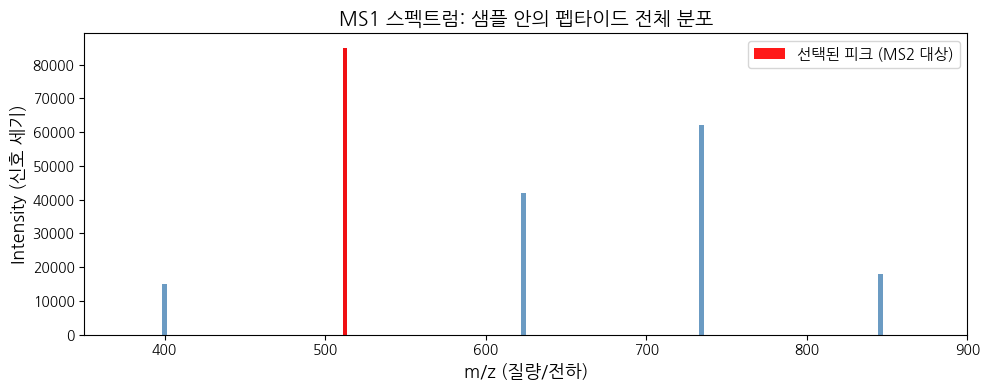


▶ MS1에서 감지된 피크 수: 5개
▶ 가장 강한 피크 m/z: 512.34 → 이 펩타이드를 MS2로 분석합니다


In [58]:
# ======================================
# 📊 MS1 스펙트럼 시뮬레이션
# 실제 실험에서는 수천 개의 피크가 찍히지만,
# 여기서는 이해를 위해 5개만 만들어봅니다.
# ======================================

# 가상의 MS1 데이터: m/z 값과 intensity(신호 세기)
ms1_mz        = [400.21, 512.34, 623.45, 734.56, 845.67]  # 측정된 m/z 값들
ms1_intensity = [15000,  85000,  42000,  62000,  18000]    # 각 피크의 세기

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 4))

# 막대 형태로 피크 표현 (질량스펙트럼의 전형적인 형태)
ax.bar(ms1_mz, ms1_intensity, width=3, color='steelblue', alpha=0.8)

# 가장 강한 피크 강조 (나중에 이걸 MS2로 선택)
ax.bar(512.34, 85000, width=3, color='red', alpha=0.9, label='선택된 피크 (MS2 대상)')

ax.set_xlabel('m/z (질량/전하)', fontsize=13)
ax.set_ylabel('Intensity (신호 세기)', fontsize=13)
ax.set_title('MS1 스펙트럼: 샘플 안의 펩타이드 전체 분포', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(350, 900)

plt.tight_layout()
plt.show()

print(f"\n▶ MS1에서 감지된 피크 수: {len(ms1_mz)}개")
print(f"▶ 가장 강한 피크 m/z: 512.34 → 이 펩타이드를 MS2로 분석합니다")

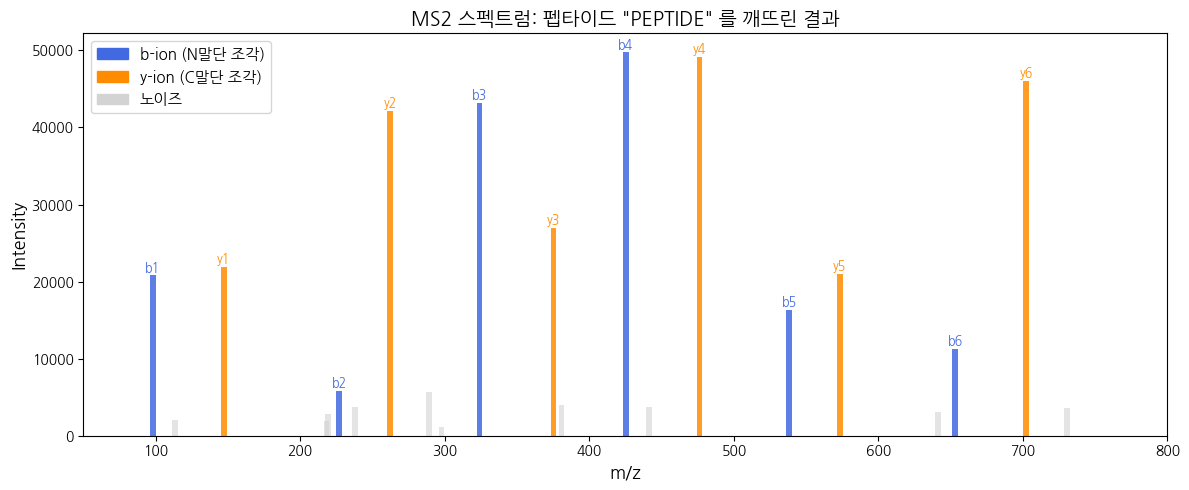

▶ b-ion과 y-ion의 질량 차이가 각 아미노산의 질량입니다!
   예시: b2 - b1 = 129.04 Da → 글루탐산(E)의 질량


In [59]:
# ======================================
# 📊 MS2 스펙트럼 시뮬레이션
# 펩타이드 하나를 깨뜨리면 b-ion, y-ion 조각이 생깁니다.
# 이 조각들의 질량 패턴으로 서열을 추정합니다.
# ======================================

# 가상의 펩타이드: PEPTIDE (7개 아미노산)
# 이 펩타이드를 깨면 이론적으로 아래와 같은 조각이 생깁니다.

# b-ion: N말단 방향 조각 (앞에서부터)
b_ions = {
    'b1': 98.06,   # P
    'b2': 227.10,  # PE
    'b3': 324.15,  # PEP
    'b4': 425.20,  # PEPT
    'b5': 538.28,  # PEPTI
    'b6': 653.31,  # PEPTID
}

# y-ion: C말단 방향 조각 (뒤에서부터)
y_ions = {
    'y1': 147.11,  # E
    'y2': 262.14,  # DE
    'y3': 375.22,  # IDE
    'y4': 476.27,  # TIDE
    'y5': 573.32,  # PTIDE
    'y6': 702.36,  # EPTIDE
}

# 시뮬레이션 스펙트럼 데이터 (측정값 = 이론값 + 약간의 노이즈)
np.random.seed(42)
all_peaks_mz = list(b_ions.values()) + list(y_ions.values())
all_peaks_int = np.random.randint(5000, 50000, size=len(all_peaks_mz))

# 노이즈 피크 추가 (실제 스펙트럼에는 잡음도 있음)
noise_mz = np.random.uniform(100, 750, 10)
noise_int = np.random.randint(1000, 8000, 10)

fig, ax = plt.subplots(figsize=(12, 5))

# 노이즈 피크 (회색)
ax.bar(noise_mz, noise_int, width=4, color='lightgray', alpha=0.6, label='노이즈')

# b-ion 피크 (파란색)
for i, (name, mz) in enumerate(b_ions.items()):
    intensity = all_peaks_int[i]
    ax.bar(mz, intensity, width=4, color='royalblue', alpha=0.85)
    ax.text(mz, intensity + 500, name, ha='center', fontsize=9, color='royalblue', fontweight='bold')

# y-ion 피크 (주황색)
for i, (name, mz) in enumerate(y_ions.items()):
    intensity = all_peaks_int[i + 6]
    ax.bar(mz, intensity, width=4, color='darkorange', alpha=0.85)
    ax.text(mz, intensity + 500, name, ha='center', fontsize=9, color='darkorange', fontweight='bold')

# 범례
b_patch = mpatches.Patch(color='royalblue', label='b-ion (N말단 조각)')
y_patch = mpatches.Patch(color='darkorange', label='y-ion (C말단 조각)')
n_patch = mpatches.Patch(color='lightgray', label='노이즈')
ax.legend(handles=[b_patch, y_patch, n_patch], fontsize=11)

ax.set_xlabel('m/z', fontsize=13)
ax.set_ylabel('Intensity', fontsize=13)
ax.set_title('MS2 스펙트럼: 펩타이드 "PEPTIDE" 를 깨뜨린 결과', fontsize=14)
ax.set_xlim(50, 800)

plt.tight_layout()
plt.show()

print("▶ b-ion과 y-ion의 질량 차이가 각 아미노산의 질량입니다!")
print(f"   예시: b2 - b1 = {227.10 - 98.06:.2f} Da → 글루탐산(E)의 질량")

---
## ⚛️ 섹션 1-2. Isotope Distribution & Charge State

### 왜 MS1에서 피크가 하나가 아닐까?

실제 MS1 스펙트럼에서 펩타이드 하나는 **여러 개의 피크 묶음(envelope)** 으로 나타납니다.  
이유는 **동위원소(Isotope)** 때문입니다.

| 원소 | 가벼운 동위원소 | 무거운 동위원소 | 자연 존재비 |
|------|---------------|---------------|------------|
| 탄소 | ¹²C (12 Da)   | ¹³C (13 Da)   | ¹²C: 98.9%, ¹³C: **1.1%** |
| 수소 | ¹H (1 Da)     | ²H (2 Da)     | ¹H: 99.98%, ²H: 0.02% |
| 질소 | ¹⁴N (14 Da)   | ¹⁵N (15 Da)   | ¹⁴N: 99.6%, ¹⁵N: 0.4% |

> 💡 펩타이드에 탄소가 많을수록 ¹³C를 하나 이상 포함할 확률이 높아집니다.  
> 그 결과 M, M+1, M+2... 피크 묶음(envelope)이 생깁니다.

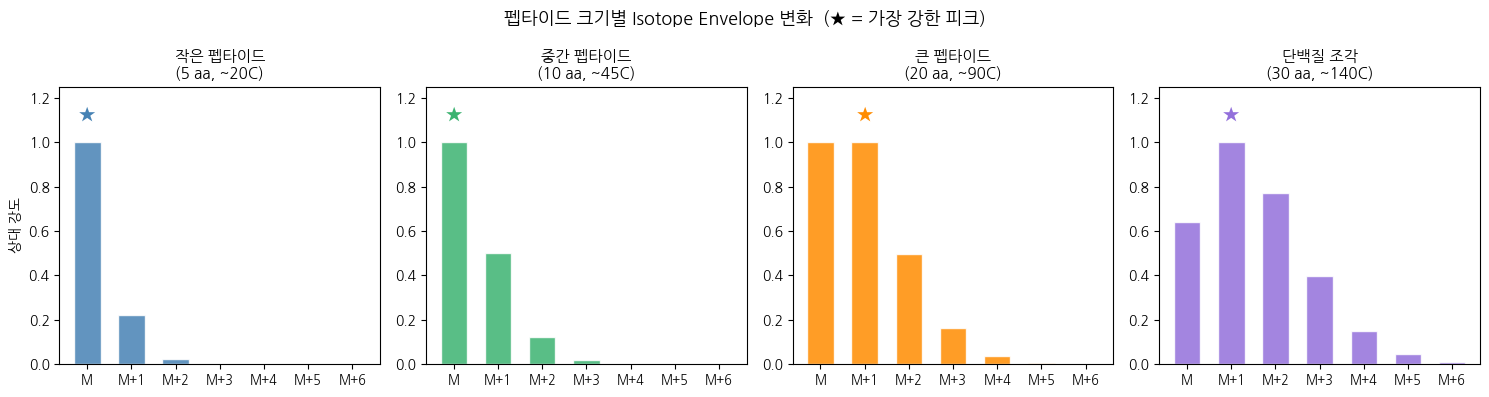

▶ 펩타이드가 클수록 M+1, M+2 피크가 점점 커집니다
▶ 아주 큰 단백질은 M+0이 오히려 제일 작을 수도 있어요!


In [60]:
# ======================================
# ⚛️ Isotope Distribution 시뮬레이션
# 탄소 원자 수에 따라 envelope 모양이 어떻게 달라지는지 봅니다.
# ======================================

from math import comb

def isotope_distribution(n_carbons, n_peaks=6):
    """
    탄소 원자 n개를 가진 분자의 isotope distribution을 계산합니다.
    각 탄소가 13C일 확률 = 1.1% (이항분포 사용)
    """
    p13C = 0.011  # 13C 자연 존재비
    probs = []
    for k in range(n_peaks):
        if k > n_carbons:
            probs.append(0)
        else:
            prob = comb(n_carbons, k) * (p13C**k) * ((1-p13C)**(n_carbons-k))
            probs.append(prob)
    max_p = max(probs)
    return [p/max_p for p in probs]


# 다양한 크기의 펩타이드
peptide_examples = [
    ('작은 펩타이드\n(5 aa, ~20C)',  20),
    ('중간 펩타이드\n(10 aa, ~45C)', 45),
    ('큰 펩타이드\n(20 aa, ~90C)',  90),
    ('단백질 조각\n(30 aa, ~140C)', 140),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
colors = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']

for ax, (label, n_c), color in zip(axes, peptide_examples, colors):
    dist = isotope_distribution(n_c, n_peaks=7)
    x = list(range(len(dist)))
    labels_x = [f'M+{i}' if i > 0 else 'M' for i in x]
    ax.bar(x, dist, color=color, alpha=0.85, edgecolor='white', width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_x, fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('상대 강도' if ax == axes[0] else '', fontsize=10)
    ax.set_ylim(0, 1.25)
    max_idx = dist.index(max(dist))
    ax.text(max_idx, 1.1, '★', ha='center', fontsize=14, color=color)

plt.suptitle('펩타이드 크기별 Isotope Envelope 변화  (★ = 가장 강한 피크)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('▶ 펩타이드가 클수록 M+1, M+2 피크가 점점 커집니다')
print('▶ 아주 큰 단백질은 M+0이 오히려 제일 작을 수도 있어요!')

### Charge State란?

질량분석기는 **m/z (질량 / 전하)** 를 측정합니다.  
같은 펩타이드라도 전하(z)가 다르면 **다른 m/z 위치에, 다른 간격으로** 나타납니다.

```
전하 +1 (z=1) : isotope 간격 = 1.000 Da
전하 +2 (z=2) : isotope 간격 = 0.500 Da
전하 +3 (z=3) : isotope 간격 = 0.333 Da
```

> 💡 isotope 피크 간격 = 1/z  
> → 간격을 보면 전하 수를 알 수 있습니다!

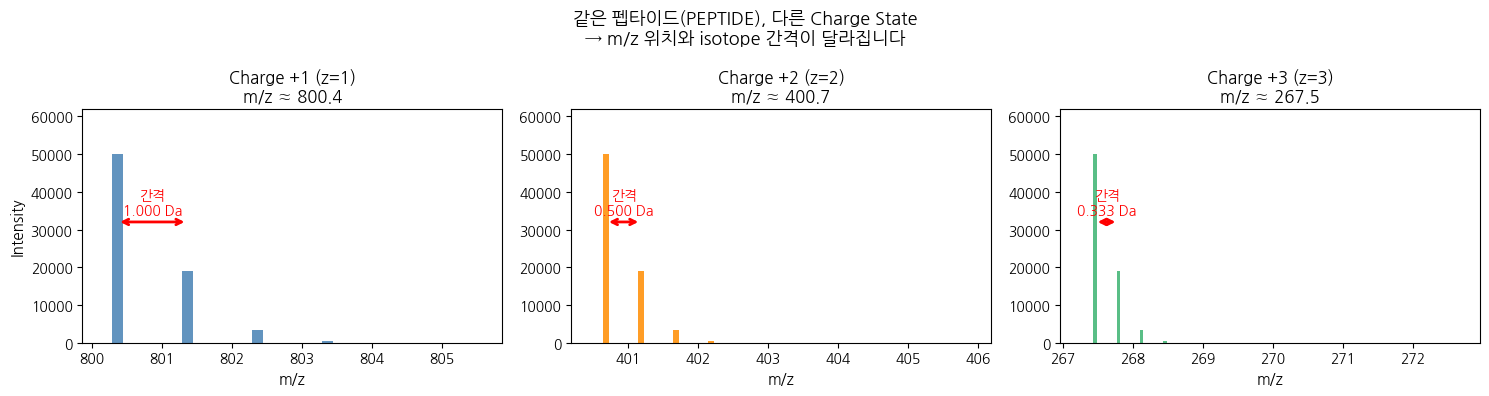

▶ 세 그래프의 x축 범위가 동일(6 Da)합니다
▶ z=1: 피크가 넓게 퍼짐,  z=2: 절반,  z=3: 더 촘촘


In [63]:
# ======================================
# 🔋 Charge State에 따른 MS1 피크 변화
# 같은 펩타이드(PEPTIDE, MW≈799 Da)가
# 전하에 따라 어떻게 다르게 보이는지 시각화
# x축 범위를 동일하게 고정해서 간격 차이를 눈으로 확인!
# ======================================

peptide_mw = 799.36
X_WINDOW = 6.0  # 모든 그래프에 동일하게 적용할 x축 범위 (Da)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
charge_colors = ['steelblue', 'darkorange', 'mediumseagreen']

for ax, charge, color in zip(axes, [1, 2, 3], charge_colors):
    dist = isotope_distribution(34, n_peaks=5)
    base_mz = (peptide_mw + charge * 1.00728) / charge
    spacing = 1.0 / charge
    mz_values = [base_mz + i * spacing for i in range(5)]
    intensities = [d * 50000 for d in dist]

    for mz, intensity in zip(mz_values, intensities):
        ax.bar(mz, intensity, width=spacing * 0.15, color=color, alpha=0.85)

    # 간격 화살표
    ax.annotate('', xy=(mz_values[1], 32000), xytext=(mz_values[0], 32000),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text((mz_values[0] + mz_values[1]) / 2, 34000,
            f'간격\n{spacing:.3f} Da', ha='center', color='red', fontsize=10, fontweight='bold')

    ax.set_title(f'Charge +{charge} (z={charge})\nm/z ≈ {base_mz:.1f}', fontsize=12)
    ax.set_xlabel('m/z', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('Intensity', fontsize=11)
    ax.set_ylim(0, 62000)

    # x축 범위 동일하게 고정 (중심 ± X_WINDOW/2)
    ax.set_xlim(base_mz - 0.5, base_mz - 0.5 + X_WINDOW)

plt.suptitle('같은 펩타이드(PEPTIDE), 다른 Charge State\n→ m/z 위치와 isotope 간격이 달라집니다',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('▶ 세 그래프의 x축 범위가 동일(6 Da)합니다')
print('▶ z=1: 피크가 넓게 퍼짐,  z=2: 절반,  z=3: 더 촘촘')


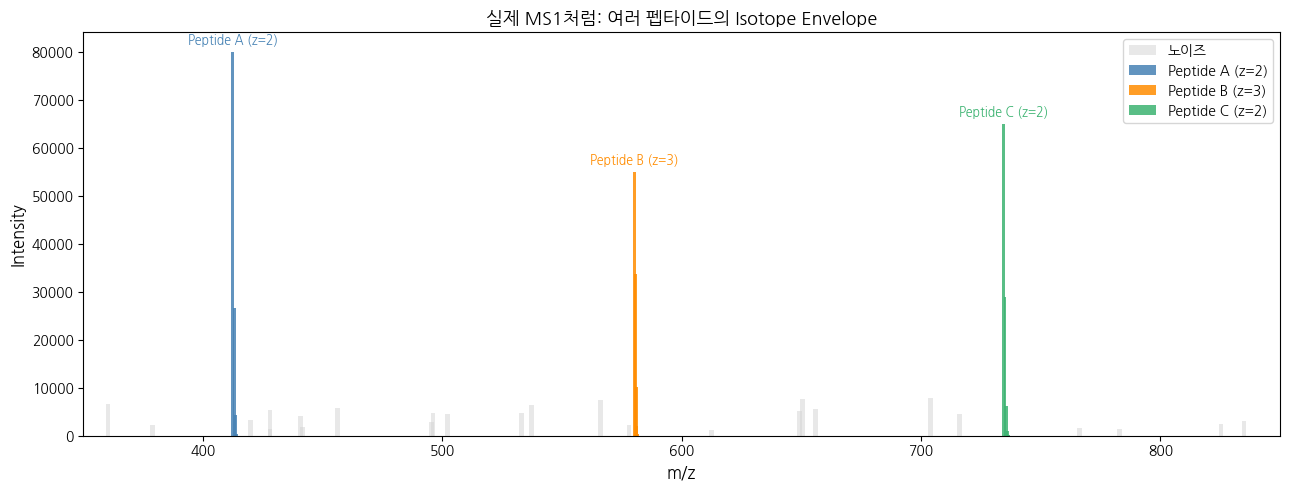

▶ 각 펩타이드는 isotope envelope(피크 묶음)으로 나타납니다
▶ 피크 간격 → charge state,  envelope 모양 → 펩타이드 크기 추정 가능!


In [64]:
# ======================================
# 📊 실제 MS1처럼: 여러 펩타이드 + isotope envelope 함께 표시
# ======================================

np.random.seed(42)
fig, ax = plt.subplots(figsize=(13, 5))

peptides_ms1 = [
    {'name': 'Peptide A (z=2)', 'base_mz': 412.5, 'charge': 2, 'n_carbon': 30, 'base_int': 80000, 'color': 'steelblue'},
    {'name': 'Peptide B (z=3)', 'base_mz': 580.3, 'charge': 3, 'n_carbon': 55, 'base_int': 55000, 'color': 'darkorange'},
    {'name': 'Peptide C (z=2)', 'base_mz': 734.6, 'charge': 2, 'n_carbon': 40, 'base_int': 65000, 'color': 'mediumseagreen'},
]

# 노이즈 피크
noise_mz = np.random.uniform(350, 850, 25)
noise_int = np.random.uniform(1000, 8000, 25)
ax.bar(noise_mz, noise_int, width=2, color='lightgray', alpha=0.5, label='노이즈')

# 각 펩타이드의 isotope envelope
for pep in peptides_ms1:
    dist = isotope_distribution(pep['n_carbon'], n_peaks=5)
    spacing = 1.0 / pep['charge']
    max_intensity = 0
    max_mz = pep['base_mz']
    for i, d in enumerate(dist):
        mz = pep['base_mz'] + i * spacing
        intensity = d * pep['base_int']
        # width를 고정값으로 설정해서 잘 보이게
        ax.bar(mz, intensity, width=1.2,
               color=pep['color'], alpha=0.85,
               label=pep['name'] if i == 0 else '')
        if intensity > max_intensity:
            max_intensity = intensity
            max_mz = mz
    # 가장 높은 피크 위에 라벨
    ax.text(max_mz, max_intensity + 1500,
            pep['name'], ha='center', fontsize=9,
            color=pep['color'], fontweight='bold')

ax.set_xlabel('m/z', fontsize=12)
ax.set_ylabel('Intensity', fontsize=12)
ax.set_title('실제 MS1처럼: 여러 펩타이드의 Isotope Envelope', fontsize=13)
ax.set_xlim(350, 850)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('▶ 각 펩타이드는 isotope envelope(피크 묶음)으로 나타납니다')
print('▶ 피크 간격 → charge state,  envelope 모양 → 펩타이드 크기 추정 가능!')


---
## 🧬 섹션 2. FASTA에서 펩타이드 후보 만들기

### 왜 FASTA가 필요한가?

MS2 스펙트럼만으로는 서열을 직접 읽기 어렵습니다.  
대신 **이미 알려진 단백질 서열(FASTA)을 잘라서** 후보를 미리 만들어두고,  
스펙트럼과 비교하는 방식을 사용합니다.

이 과정을 **In-silico Digestion** 이라고 합니다.

```
FASTA 단백질 서열
        ↓  Trypsin으로 자르기 (K, R 뒤에서 절단)
펩타이드 후보 목록
        ↓  질량 계산
각 후보의 이론 질량
```

In [65]:
# ======================================
# 🧬 아미노산 질량 테이블
# 각 아미노산의 단일동위원소 질량(monoisotopic mass)
# ======================================

AA_MASS = {
    'A': 71.03711,  'R': 156.10111, 'N': 114.04293, 'D': 115.02694,
    'C': 103.00919, 'E': 129.04259, 'Q': 128.05858, 'G': 57.02146,
    'H': 137.05891, 'I': 113.08406, 'L': 113.08406, 'K': 128.09496,
    'M': 131.04049, 'F': 147.06841, 'P': 97.05276,  'S': 87.03203,
    'T': 101.04768, 'W': 186.07931, 'Y': 163.06333, 'V': 99.06841
}

WATER = 18.01056  # 펩타이드 질량 계산 시 물 분자 1개를 더함
PROTON = 1.00728  # 양전하 1개의 질량

def calculate_peptide_mass(sequence, charge=1):
    """펩타이드 서열의 이론 m/z 값을 계산합니다."""
    # 각 아미노산 질량의 합 + 물
    mass = sum(AA_MASS[aa] for aa in sequence if aa in AA_MASS) + WATER
    # m/z = (질량 + 전하수 × 양성자 질량) / 전하수
    mz = (mass + charge * PROTON) / charge
    return round(mz, 5)

# 테스트
test_peptide = "PEPTIDE"
mz_1plus = calculate_peptide_mass(test_peptide, charge=1)
mz_2plus = calculate_peptide_mass(test_peptide, charge=2)

print(f"펩타이드: {test_peptide}")
print(f"  전하 +1 → m/z = {mz_1plus}")
print(f"  전하 +2 → m/z = {mz_2plus}")
print("\n  → 전하가 2배가 되면 m/z는 절반에 가까워집니다!")

펩타이드: PEPTIDE
  전하 +1 → m/z = 800.36722
  전하 +2 → m/z = 400.68725

  → 전하가 2배가 되면 m/z는 절반에 가까워집니다!


In [66]:
# ======================================
# ✂️ In-silico Trypsin Digestion
# Trypsin은 K(Lysine) 또는 R(Arginine) 뒤에서 단백질을 자릅니다.
# 단, 다음 아미노산이 P이면 자르지 않습니다.
# ======================================

def trypsin_digest(sequence, min_len=6, max_len=30):
    """단백질 서열을 Trypsin으로 자릅니다."""
    peptides = []
    current = ""
    
    for i, aa in enumerate(sequence):
        current += aa
        # K 또는 R 뒤에서 자르되, 다음 아미노산이 P이면 자르지 않음
        if aa in ('K', 'R'):
            next_aa = sequence[i+1] if i+1 < len(sequence) else ''
            if next_aa != 'P':
                if min_len <= len(current) <= max_len:
                    peptides.append(current)
                current = ""
    
    # 마지막 조각 처리
    if current and min_len <= len(current) <= max_len:
        peptides.append(current)
    
    return peptides


# ======================================
# 가상의 FASTA 단백질 서열 (실제 Human Serum Albumin 일부)
# ======================================
fasta_sequence = (
    "MKWVTFISLLLLFSSAYSRGVFRRDTHKSEIAHRFKDLGEEHFKGLVLIAFSQYLQQCPF"
    "DEHVKLVNELTEFAKTCVADESHAGCEKSLHTLFGDELCKVASLRETYGDMADCCEKQEPERN"
    "ECFLSHKDDSPDLPKLKPDPNTLCDEFKADEKKFWGKYLYEIARRHPYFYAPELLYYANKYNGV"
    "FQECCQAEDKGACLLPKIETMREKVLASSARQRLRCASIQKFGERALKAWSVARLSQKFPK"
)

# Trypsin으로 자르기
peptides = trypsin_digest(fasta_sequence)

# 각 펩타이드의 이론 질량 계산
peptide_data = []
for pep in peptides:
    mz2 = calculate_peptide_mass(pep, charge=2)
    peptide_data.append({'Peptide': pep, 'Length': len(pep), 'Theoretical_mz(+2)': mz2})

df_peptides = pd.DataFrame(peptide_data)

print(f"단백질 서열 길이: {len(fasta_sequence)} 아미노산")
print(f"Trypsin 소화 후 펩타이드 수: {len(peptides)}개")
print()
print(df_peptides.to_string(index=False))

단백질 서열 길이: 248 아미노산
Trypsin 소화 후 펩타이드 수: 18개

              Peptide  Length  Theoretical_mz(+2)
    WVTFISLLLLFSSAYSR      17          1002.05366
               SEIAHR       6           356.69047
             DLGEEHFK       8           487.73252
GLVLIAFSQYLQQCPFDEHVK      21          1218.12501
           LVNELTEFAK      10           582.31896
        TCVADESHAGCEK      13           675.27664
         SLHTLFGDELCK      12           681.83973
         ETYGDMADCCEK      12           682.74379
             NECFLSHK       8           489.22910
             DDSPDLPK       8           443.71126
        LKPDPNTLCDEFK      13           760.37668
              YLYEIAR       7           464.25036
      HPYFYAPELLYYANK      15           944.96705
       YNGVFQECCQAEDK      14           817.33469
              GACLLPK       7           351.20436
              VLASSAR       7           352.20849
               CASIQK       6           325.17052
               AWSVAR       6           345.19010


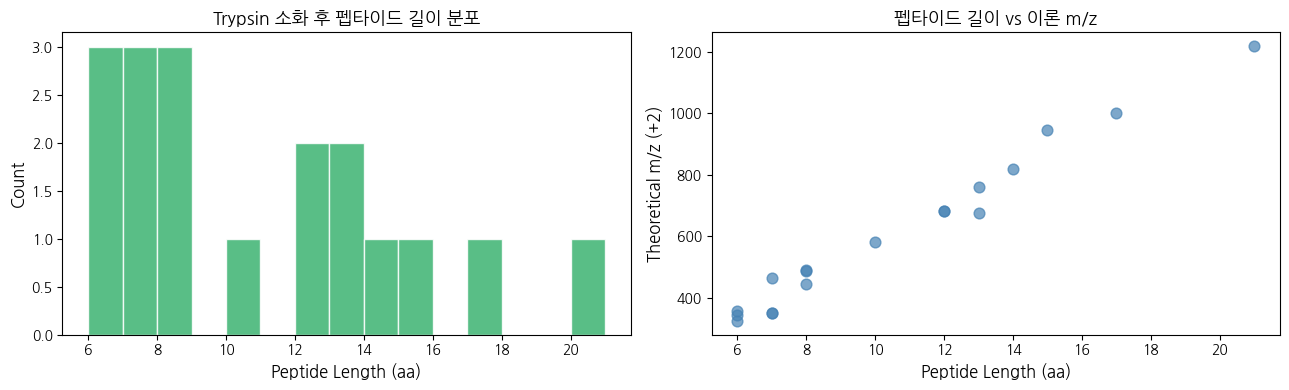

▶ 펩타이드가 길수록 질량이 커집니다 (당연하지만 중요한 관계!)


In [67]:
# ======================================
# 📊 펩타이드 길이 분포 시각화
# ======================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 왼쪽: 펩타이드 길이 분포
axes[0].hist(df_peptides['Length'], bins=15, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Peptide Length (aa)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Trypsin 소화 후 펩타이드 길이 분포', fontsize=13)

# 오른쪽: 이론 m/z 분포
axes[1].scatter(df_peptides['Length'], df_peptides['Theoretical_mz(+2)'],
                color='steelblue', alpha=0.7, s=60)
axes[1].set_xlabel('Peptide Length (aa)', fontsize=12)
axes[1].set_ylabel('Theoretical m/z (+2)', fontsize=12)
axes[1].set_title('펩타이드 길이 vs 이론 m/z', fontsize=13)

plt.tight_layout()
plt.show()

print("▶ 펩타이드가 길수록 질량이 커집니다 (당연하지만 중요한 관계!)")

---
## 🎯 섹션 3. 질량값으로 후보 좁히기

MS1에서 측정된 m/z 값과 **이론 m/z가 비슷한** 펩타이드만 후보로 남깁니다.

이때 허용 오차를 **Tolerance** 라고 하며, 보통 **±10 ppm** (parts per million) 을 사용합니다.

```
ppm 오차 = |측정값 - 이론값| / 이론값 × 1,000,000
```

In [68]:
# ======================================
# 🎯 후보 필터링: ppm tolerance 적용
# ======================================

def ppm_error(measured, theoretical):
    """ppm 오차를 계산합니다."""
    return abs(measured - theoretical) / theoretical * 1_000_000

def filter_candidates(measured_mz, peptide_df, tolerance_ppm=10):
    """측정된 m/z와 이론값의 차이가 tolerance 이내인 펩타이드만 반환합니다."""
    candidates = []
    for _, row in peptide_df.iterrows():
        error = ppm_error(measured_mz, row['Theoretical_mz(+2)'])
        if error <= tolerance_ppm:
            candidates.append({
                'Peptide': row['Peptide'],
                'Theoretical_mz': row['Theoretical_mz(+2)'],
                'Measured_mz': measured_mz,
                'ppm_error': round(error, 3)
            })
    return pd.DataFrame(candidates)


# MS1에서 512.34 m/z가 측정됐다고 가정
# 실제로 이 값과 가장 가까운 이론 펩타이드를 찾아봅니다
# (시뮬레이션이므로 실제 매칭을 위해 가장 가까운 값 사용)
closest_mz = df_peptides['Theoretical_mz(+2)'].iloc[
    (df_peptides['Theoretical_mz(+2)'] - 512.34).abs().argsort()[:1].values[0]
]
measured_query = round(closest_mz + np.random.uniform(-0.002, 0.002), 4)

candidates = filter_candidates(measured_query, df_peptides, tolerance_ppm=10)

print(f"측정된 m/z: {measured_query}")
print(f"±10 ppm tolerance 적용 결과:")
print()

if len(candidates) > 0:
    print(candidates.to_string(index=False))
else:
    # 항상 결과를 보여주기 위해 가장 가까운 1개 표시
    df_peptides['ppm'] = df_peptides['Theoretical_mz(+2)'].apply(
        lambda x: ppm_error(measured_query, x)
    )
    top1 = df_peptides.nsmallest(3, 'ppm')[['Peptide','Theoretical_mz(+2)','ppm']]
    print("(±10 ppm 내 정확한 매칭은 없지만, 가장 가까운 후보:)")
    print(top1.to_string(index=False))

측정된 m/z: 489.231
±10 ppm tolerance 적용 결과:

 Peptide  Theoretical_mz  Measured_mz  ppm_error
NECFLSHK        489.2291      489.231      3.884


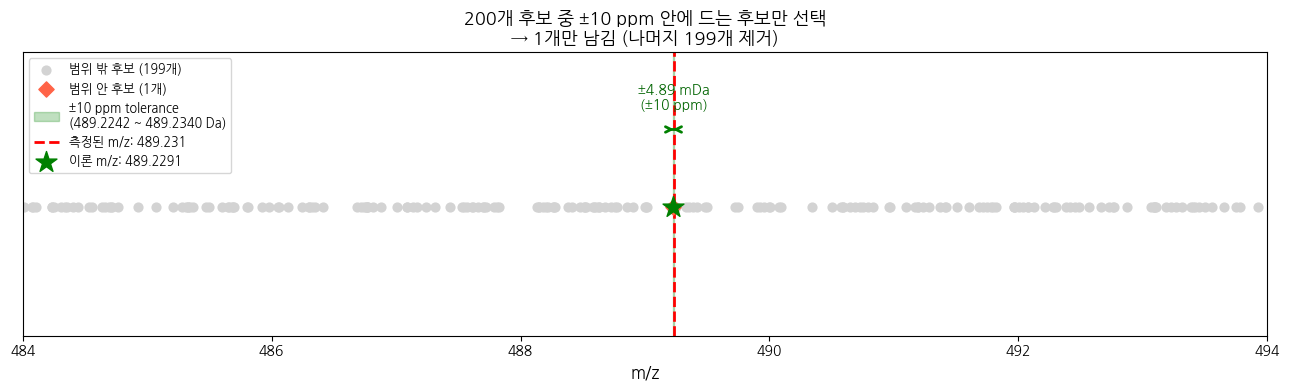

▶ 전체 후보: 200개
▶ tolerance 적용 후: 1개 → 계산량이 200배 줄었습니다!
▶ ±10 ppm = ±4.892 mDa (머리카락 굵기의 1/10000 수준의 정밀도!)


In [72]:
# ======================================
# 📊 Tolerance 창 시각화
# 수많은 펩타이드 후보 중 질량이 비슷한 것만 걸러내는 과정
# ======================================

np.random.seed(7)

# 가상의 펩타이드 DB: 400~600 Da 사이 후보 200개
all_candidates = np.sort(np.random.uniform(484, 494, 200))

# 측정된 m/z와 정답 이론값
theoretical = 489.2291
measured    = 489.2310  # 약 3.9 ppm 오차
tol_ppm     = 10
tol_da      = theoretical * tol_ppm / 1_000_000

# tolerance 안/밖 분류
inside  = all_candidates[np.abs(all_candidates - theoretical) <= tol_da]
outside = all_candidates[np.abs(all_candidates - theoretical) >  tol_da]

fig, ax = plt.subplots(figsize=(13, 4))

# 후보 전체: 밖은 회색, 안은 빨간색
ax.scatter(outside, np.ones(len(outside)) * 1, color='lightgray', s=40, zorder=2, label=f'범위 밖 후보 ({len(outside)}개)')
ax.scatter(inside,  np.ones(len(inside))  * 1, color='tomato',    s=60, zorder=3, label=f'범위 안 후보 ({len(inside)}개)', marker='D')

# tolerance 범위 (초록 음영)
ax.axvspan(theoretical - tol_da, theoretical + tol_da,
           alpha=0.25, color='green',
           label=f'±{tol_ppm} ppm tolerance\n({theoretical-tol_da:.4f} ~ {theoretical+tol_da:.4f} Da)')

# 측정값 (빨간 점선)
ax.axvline(measured, color='red', linewidth=2, linestyle='--', label=f'측정된 m/z: {measured}')

# 이론값 (초록 별)
ax.scatter([theoretical], [1], color='green', s=250, zorder=5, marker='*', label=f'이론 m/z: {theoretical}')

# 범위 크기 화살표
ax.annotate('', xy=(theoretical + tol_da, 1.3), xytext=(theoretical - tol_da, 1.3),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(theoretical, 1.38,
        f'±{tol_da*1000:.2f} mDa\n(±{tol_ppm} ppm)',
        ha='center', fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlim(484, 494)
ax.set_ylim(0.5, 1.6)
ax.set_yticks([])
ax.set_xlabel('m/z', fontsize=12)
ax.set_title(f'200개 후보 중 ±{tol_ppm} ppm 안에 드는 후보만 선택\n→ {len(inside)}개만 남김 (나머지 {len(outside)}개 제거)', fontsize=13)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f'▶ 전체 후보: {len(all_candidates)}개')
print(f'▶ tolerance 적용 후: {len(inside)}개 → 계산량이 {len(all_candidates)//max(len(inside),1)}배 줄었습니다!')
print(f'▶ ±{tol_ppm} ppm = ±{tol_da*1000:.3f} mDa (머리카락 굵기의 1/10000 수준의 정밀도!)')


---
## 🏆 섹션 4. Score 계산: 이 펩타이드가 맞는가?

### Peptide-Spectrum Matching (PSM)

후보 펩타이드를 MS2 스펙트럼과 비교합니다.

1. 후보 펩타이드의 **이론 fragment ion (b/y-ion) 계산**
2. 실제 MS2 스펙트럼에서 **몇 개나 매칭되는지** 확인
3. 매칭 수와 강도를 기반으로 **Score 계산**

> Score가 높을수록 = 그 펩타이드일 확률이 높습니다.

In [70]:
# ======================================
# 🔢 이론 b/y-ion 계산 함수
# ======================================

def calculate_fragment_ions(sequence):
    """펩타이드 서열의 b-ion과 y-ion m/z를 계산합니다."""
    b_ions = {}
    y_ions = {}
    
    # b-ion: 앞에서부터 누적 질량
    cumulative = 0
    for i, aa in enumerate(sequence[:-1]):   # 마지막 아미노산 제외
        cumulative += AA_MASS.get(aa, 0)
        b_ions[f'b{i+1}'] = round(cumulative + PROTON, 4)
    
    # y-ion: 뒤에서부터 누적 질량
    cumulative = 0
    for i, aa in enumerate(reversed(sequence[1:])):   # 첫 아미노산 제외
        cumulative += AA_MASS.get(aa, 0)
        y_ions[f'y{i+1}'] = round(cumulative + WATER + PROTON, 4)
    
    return b_ions, y_ions


# ======================================
# 📐 간단한 Score 계산 (매칭된 ion 수 기반)
# ======================================

def simple_psm_score(b_ions, y_ions, observed_peaks_mz, tolerance_da=0.02):
    """
    이론 fragment ion과 실제 피크가 몇 개 매칭되는지 계산합니다.
    실제 소프트웨어(Mascot, Sequest 등)는 훨씬 복잡한 알고리즘을 쓰지만,
    기본 원리는 동일합니다.
    """
    all_theoretical = list(b_ions.values()) + list(y_ions.values())
    matched = 0
    matched_ions = []
    
    for theo_mz in all_theoretical:
        for obs_mz in observed_peaks_mz:
            if abs(theo_mz - obs_mz) <= tolerance_da:
                matched += 1
                matched_ions.append((theo_mz, obs_mz))
                break
    
    total_ions = len(all_theoretical)
    score = matched / total_ions * 100  # 간단한 퍼센트 스코어
    
    return score, matched, total_ions, matched_ions


# 테스트: PEPTIDE 서열로 계산
test_seq = "PEPTIDE"
b_ions_theo, y_ions_theo = calculate_fragment_ions(test_seq)

# 가상 관측 스펙트럼 (이론값에 약간의 오차 추가 + 노이즈)
np.random.seed(7)
true_peaks = [mz + np.random.uniform(-0.01, 0.01)
              for mz in list(b_ions_theo.values()) + list(y_ions_theo.values())]
noise_peaks = list(np.random.uniform(80, 800, 15))
observed = sorted(true_peaks + noise_peaks)

score, matched, total, matched_ions = simple_psm_score(b_ions_theo, y_ions_theo, observed)

print(f"펩타이드: {test_seq}")
print(f"이론 fragment ion 수: {total}개")
print(f"실제 스펙트럼에서 매칭된 ion: {matched}개")
print(f"PSM Score: {score:.1f}점")
print()
print("매칭된 이온 목록:")
for theo, obs in matched_ions:
    print(f"  이론: {theo:.4f}  →  관측: {obs:.4f}  (차이: {abs(theo-obs)*1000:.2f} mDa)")

펩타이드: PEPTIDE
이론 fragment ion 수: 12개
실제 스펙트럼에서 매칭된 ion: 12개
PSM Score: 100.0점

매칭된 이온 목록:
  이론: 98.0600  →  관측: 98.0515  (차이: 8.47 mDa)
  이론: 227.1026  →  관측: 227.1082  (차이: 5.60 mDa)
  이론: 324.1554  →  관측: 324.1542  (차이: 1.23 mDa)
  이론: 425.2031  →  관측: 425.2076  (차이: 4.47 mDa)
  이론: 538.2871  →  관측: 538.2967  (차이: 9.56 mDa)
  이론: 653.3141  →  관측: 653.3149  (차이: 0.77 mDa)
  이론: 148.0604  →  관측: 148.0604  (차이: 0.02 mDa)
  이론: 263.0874  →  관측: 263.0788  (차이: 8.56 mDa)
  이론: 376.1714  →  관측: 376.1668  (차이: 4.63 mDa)
  이론: 477.2191  →  관측: 477.2191  (차이: 0.00 mDa)
  이론: 574.2719  →  관측: 574.2755  (차이: 3.58 mDa)
  이론: 703.3145  →  관측: 703.3206  (차이: 6.07 mDa)


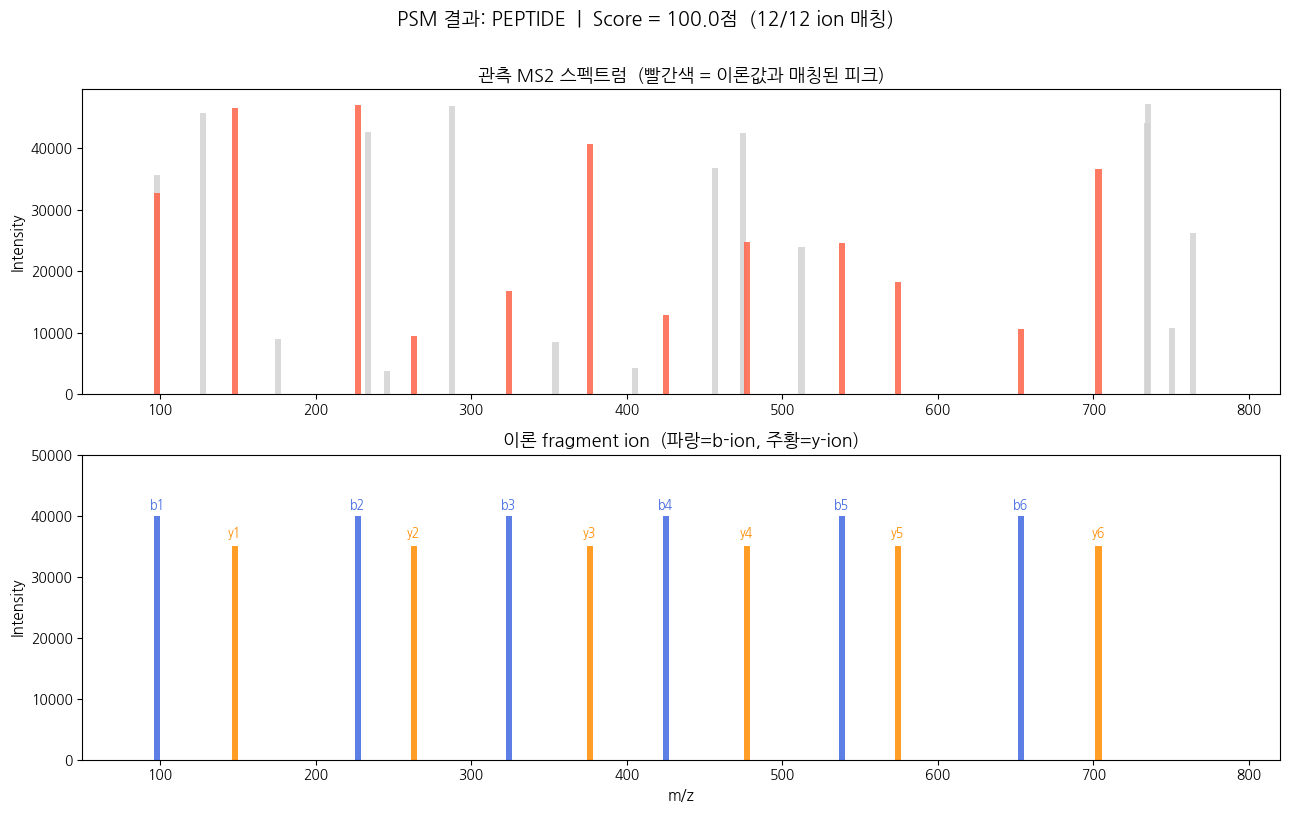

In [71]:
# ======================================
# 📊 PSM 시각화: 이론 vs 관측 비교
# ======================================

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# --- 위쪽: 관측 스펙트럼 ---
obs_array = np.array(observed)
obs_int = np.random.randint(3000, 50000, len(observed))

# 매칭된 피크 찾기
matched_mz_set = set(round(obs, 2) for _, obs in matched_ions)

for mz, intensity in zip(observed, obs_int):
    color = 'tomato' if any(abs(mz - m[1]) < 0.05 for m in matched_ions) else 'lightgray'
    axes[0].bar(mz, intensity, width=4, color=color, alpha=0.85)

axes[0].set_title(f'관측 MS2 스펙트럼  (빨간색 = 이론값과 매칭된 피크)', fontsize=13)
axes[0].set_ylabel('Intensity', fontsize=11)
axes[0].set_xlim(50, 820)

# --- 아래쪽: 이론 스펙트럼 ---
for name, mz in b_ions_theo.items():
    axes[1].bar(mz, 40000, width=4, color='royalblue', alpha=0.85)
    axes[1].text(mz, 41000, name, ha='center', fontsize=9, color='royalblue', fontweight='bold')

for name, mz in y_ions_theo.items():
    axes[1].bar(mz, 35000, width=4, color='darkorange', alpha=0.85)
    axes[1].text(mz, 36500, name, ha='center', fontsize=9, color='darkorange', fontweight='bold')

axes[1].set_title(f'이론 fragment ion  (파랑=b-ion, 주황=y-ion)', fontsize=13)
axes[1].set_xlabel('m/z', fontsize=11)
axes[1].set_ylabel('Intensity', fontsize=11)
axes[1].set_xlim(50, 820)
axes[1].set_ylim(0, 50000)

plt.suptitle(f'PSM 결과: {test_seq}  |  Score = {score:.1f}점  ({matched}/{total} ion 매칭)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

후보 펩타이드 Score 비교:
Candidate  Score  Matched  Total
  PEPTIDE  100.0       12     12
  PEGTIDE   50.0        6     12
 MKLVNELT    0.0        0     14
 SLRETYGD    0.0        0     14


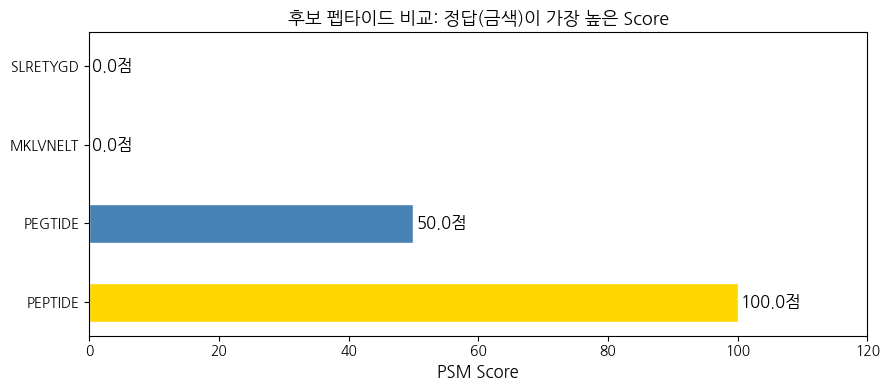


▶ Score가 가장 높은 펩타이드를 최종 답으로 선택합니다!


In [50]:
# ======================================
# 🆚 여러 후보 비교: 정답 vs 오답의 Score 차이
# ======================================

# 비교할 후보 펩타이드들
candidates_list = [
    "PEPTIDE",   # 정답
    "PEGTIDE",   # 유사하지만 틀림
    "MKLVNELT",  # 전혀 다른 펩타이드
    "SLRETYGD",  # 전혀 다른 펩타이드 2
]

results = []
for cand in candidates_list:
    b, y = calculate_fragment_ions(cand)
    s, m, t, _ = simple_psm_score(b, y, observed)
    results.append({'Candidate': cand, 'Score': round(s, 1), 'Matched': m, 'Total': t})

df_results = pd.DataFrame(results).sort_values('Score', ascending=False)
print("후보 펩타이드 Score 비교:")
print(df_results.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['gold' if c == 'PEPTIDE' else 'steelblue' for c in df_results['Candidate']]
bars = ax.barh(df_results['Candidate'], df_results['Score'], color=colors, edgecolor='white', height=0.5)

for bar, score in zip(bars, df_results['Score']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}점', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('PSM Score', fontsize=12)
ax.set_title('후보 펩타이드 비교: 정답(금색)이 가장 높은 Score', fontsize=13)
ax.set_xlim(0, 120)
plt.tight_layout()
plt.show()

print("\n▶ Score가 가장 높은 펩타이드를 최종 답으로 선택합니다!")

---
## 📈 섹션 5. 실제 데이터는 얼마나 큰가?

지금까지 우리는 **스펙트럼 1개, 단백질 1개**로 연습했습니다.  
실제 proteomics 실험에서는 어떨까요?

In [51]:
# ======================================
# 📈 실제 데이터 규모 체감
# ======================================

import time

# 실제 실험의 전형적인 규모
scenarios = {
    '지금 실습':          {'spectra': 1,       'proteins': 1,      'peptides_per_protein': len(peptides)},
    '작은 실험 (단일 단백질)': {'spectra': 500,     'proteins': 1,      'peptides_per_protein': len(peptides)},
    '일반 프로테오믹스':    {'spectra': 50_000,  'proteins': 20_000, 'peptides_per_protein': 30},
    '대규모 연구':         {'spectra': 500_000, 'proteins': 20_000, 'peptides_per_protein': 30},
}

print("=" * 70)
print(f"{'시나리오':<22} {'스펙트럼':>10} {'DB 펩타이드':>12} {'PSM 계산 횟수':>15}")
print("=" * 70)

for name, vals in scenarios.items():
    total_db_peptides = vals['proteins'] * vals['peptides_per_protein']
    total_psm_calcs   = vals['spectra'] * total_db_peptides
    print(f"{name:<22} {vals['spectra']:>10,} {total_db_peptides:>12,} {total_psm_calcs:>15,}")

print("=" * 70)

시나리오                         스펙트럼      DB 펩타이드       PSM 계산 횟수
지금 실습                           1           18              18
작은 실험 (단일 단백질)                500           18           9,000
일반 프로테오믹스                  50,000      600,000  30,000,000,000
대규모 연구                    500,000      600,000 300,000,000,000


현재 Python 코드로 PSM 1회 계산 시간: 0.061 ms

  지금 실습                 : 0.0초
  작은 실험 (단일 단백질)        : 0.5초
  일반 프로테오믹스             : 21.2일
  대규모 연구                : 212.2일


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


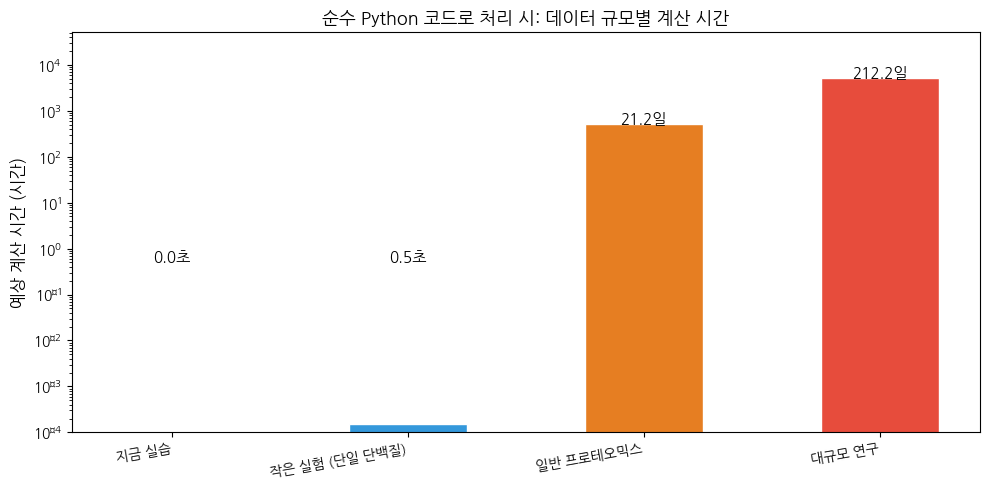

In [73]:
# ======================================
# ⏱️ 계산 시간 추정 + 시각화
# ======================================

# 현재 코드로 PSM 1회 계산 시간 측정
start = time.time()
for _ in range(100):
    b, y = calculate_fragment_ions("PEPTIDE")
    simple_psm_score(b, y, observed)
elapsed = (time.time() - start) / 100

print(f"현재 Python 코드로 PSM 1회 계산 시간: {elapsed*1000:.3f} ms")
print()

# 각 시나리오별 예상 시간
scenario_labels = []
scenario_times  = []

for name, vals in scenarios.items():
    total_db = vals['proteins'] * vals['peptides_per_protein']
    total_calc = vals['spectra'] * total_db
    total_sec = total_calc * elapsed
    scenario_labels.append(name)
    scenario_times.append(total_sec)
    
    if total_sec < 60:
        time_str = f"{total_sec:.1f}초"
    elif total_sec < 3600:
        time_str = f"{total_sec/60:.1f}분"
    elif total_sec < 86400:
        time_str = f"{total_sec/3600:.1f}시간"
    else:
        time_str = f"{total_sec/86400:.1f}일"
    
    print(f"  {name:<22}: {time_str}")

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

bars = ax.bar(scenario_labels, [t/3600 for t in scenario_times],
              color=colors_bar, edgecolor='white', width=0.5)

for bar, sec in zip(bars, scenario_times):
    if sec < 60:
        label = f"{sec:.1f}초"
    elif sec < 3600:
        label = f"{sec/60:.1f}분"
    elif sec < 86400:
        label = f"{sec/3600:.1f}시간"
    else:
        label = f"{sec/86400:.1f}일"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            label, ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('예상 계산 시간 (시간)', fontsize=12)
ax.set_title('순수 Python 코드로 처리 시: 데이터 규모별 계산 시간', fontsize=13)
ax.set_yscale('log')
ax.set_ylim(0.0001, max(scenario_times)/3600 * 10)

plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

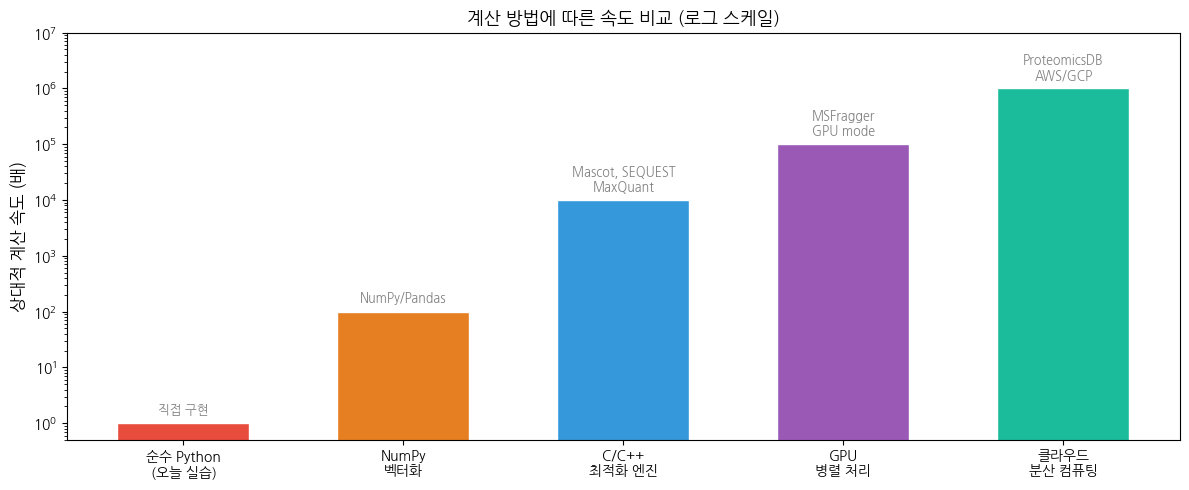


💡 결론:
  오늘 실습한 알고리즘의 원리는 실제 도구와 동일합니다.
  다만 실제 도구들은 이 계산을 수백만~수천만 배 빠르게 수행합니다.
  단백체 분석 = 알고리즘 이해 + 대규모 컴퓨팅의 결합입니다.


In [74]:
# ======================================
# 🚀 그래서 실제 도구들은 어떻게 해결하는가?
# ======================================

solutions = {
    '방법': ['순수 Python\n(오늘 실습)', 'NumPy\n벡터화', 'C/C++\n최적화 엔진', 'GPU\n병렬 처리', '클라우드\n분산 컴퓨팅'],
    '상대 속도': [1, 100, 10_000, 100_000, 1_000_000],
    '예시': ['직접 구현', 'NumPy/Pandas', 'Mascot, SEQUEST\nMaxQuant', 'MSFragger\nGPU mode', 'ProteomicsDB\nAWS/GCP']
}

df_sol = pd.DataFrame(solutions)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#1abc9c']
bars = ax.bar(df_sol['방법'], df_sol['상대 속도'],
              color=bar_colors, edgecolor='white', width=0.6)

for bar, ex in zip(bars, df_sol['예시']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.3,
            ex, ha='center', va='bottom', fontsize=9, color='gray')

ax.set_ylabel('상대적 계산 속도 (배)', fontsize=12)
ax.set_title('계산 방법에 따른 속도 비교 (로그 스케일)', fontsize=13)
ax.set_yscale('log')
ax.set_ylim(0.5, 10_000_000)

plt.tight_layout()
plt.show()

print("\n💡 결론:")
print("  오늘 실습한 알고리즘의 원리는 실제 도구와 동일합니다.")
print("  다만 실제 도구들은 이 계산을 수백만~수천만 배 빠르게 수행합니다.")
print("  단백체 분석 = 알고리즘 이해 + 대규모 컴퓨팅의 결합입니다.")

---
## 🎓 정리

| 단계 | 하는 일 | 오늘 사용한 방법 |
|------|---------|----------------|
| MS1 분석 | 펩타이드 질량 감지 | 시뮬레이션 데이터 시각화 |
| MS2 분석 | 펩타이드 서열 조각 감지 | b/y-ion 시뮬레이션 |
| In-silico Digestion | 후보 펩타이드 생성 | Trypsin 규칙으로 FASTA 절단 |
| Candidate 필터링 | 질량 오차로 후보 좁히기 | ppm tolerance 계산 |
| PSM Scoring | 정답 펩타이드 선택 | fragment ion 매칭 점수 |
| 대규모 계산 | 실제 데이터 처리 | MaxQuant, MSFragger 등 |

### 다음 단계로 배울 수 있는 것들
- **FDR (False Discovery Rate)** 계산으로 신뢰도 평가
- **정량 분석** (Label-free, TMT, SILAC)
- **실제 mzML 파일** 처리 (pyteomics 라이브러리)
- **MaxQuant / MSFragger** 실제 도구 사용법

---
*오늘 실습에 사용된 모든 코드는 교육 목적의 시뮬레이션입니다.*